# Day 3 - Exploratory Data Analysis (EDA)

This notebook contains:
- NAV Trend Analysis
- AUM Growth Analysis
- SIP Inflow Analysis
- Category Inflow Heatmap
- Investor Demographics
- Geographic Distribution
- Folio Growth Analysis
- NAV Correlation Analysis
- Sector Allocation Analysis
- Key Insights

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

plt.style.use("default")

print("Libraries loaded successfully")

Libraries loaded successfully


In [10]:
fund_master = pd.read_csv("../data/raw/fund_master.csv")
nav_history = pd.read_csv("../data/raw/nav_history.csv")

aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")
sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")
category = pd.read_csv("../data/raw/05_category_inflows.csv")
folio = pd.read_csv("../data/raw/06_industry_folio_count.csv")
performance = pd.read_csv("../data/raw/07_scheme_performance.csv")
transactions = pd.read_csv("../data/raw/08_investor_transactions.csv")
holdings = pd.read_csv("../data/raw/09_portfolio_holdings.csv")
benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

print("All datasets loaded")

All datasets loaded


In [11]:
datasets = {
    "fund_master": fund_master,
    "nav_history": nav_history,
    "aum": aum,
    "sip": sip,
    "category": category,
    "folio": folio,
    "performance": performance,
    "transactions": transactions,
    "holdings": holdings,
    "benchmark": benchmark
}

for name, df in datasets.items():
    print(f"{name}: {df.shape}")

fund_master: (15484, 6)
nav_history: (19798, 3)
aum: (90, 5)
sip: (48, 6)
category: (144, 3)
folio: (21, 6)
performance: (40, 19)
transactions: (32778, 13)
holdings: (322, 8)
benchmark: (8050, 3)


In [16]:
nav_history["date"] = pd.to_datetime(
    nav_history["date"],
    dayfirst=True
)

nav_history = nav_history.sort_values("date")

nav_history.head()

,date,nav,source_file
6871,2012-12-31,23.9920,axis_bluechip.csv
6870,2013-01-01,23.9979,axis_bluechip.csv
10169,2013-01-02,14.6967,nippon_largecap.csv
6869,2013-01-02,24.0036,axis_bluechip.csv
13405,2013-01-02,103.0059,sbi_bluechip.csv


# NAV Trend Analysis

Objective:
- Study NAV movement across schemes
- Identify market rallies and corrections
- Understand long-term growth trends

In [21]:
top_funds = (
    nav_history["source_file"]
    .value_counts()
    .head(5)
    .index
)

nav_top = nav_history[
    nav_history["source_file"].isin(top_funds)
]

nav_top.head()

,date,nav,source_file
6871,2012-12-31,23.9920,axis_bluechip.csv
6870,2013-01-01,23.9979,axis_bluechip.csv
10169,2013-01-02,14.6967,nippon_largecap.csv
6869,2013-01-02,24.0036,axis_bluechip.csv
13405,2013-01-02,103.0059,sbi_bluechip.csv


In [25]:
fig = px.line(
    nav_top,
    x="date",
    y="nav",
    color="source_file",
    title="Daily NAV Trend - Top Mutual Fund Schemes"
)

fig.show()

## Insight 1

The selected mutual fund schemes show a long-term upward NAV trend, indicating steady wealth creation over time. Different schemes exhibit different growth rates, with some funds significantly outperforming others.

In [28]:
nav_top["nav"] = pd.to_numeric(nav_top["nav"], errors="coerce")

fig = px.line(
    nav_top,
    x="date",
    y="nav",
    color="source_file",
    title="Daily NAV Trend by Fund"
)

fig.update_layout(
    xaxis_title="Date",
    yaxis_title="NAV",
    template="plotly_white"
)

fig.show()

/var/folders/vy/vwj5nqcd1935lpj277_j746h0000gn/T/ipykernel_15194/312841398.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nav_top["nav"] = pd.to_numeric(nav_top["nav"], errors="coerce")


In [30]:
fig.write_image("../reports/nav_trend.png")
print("NAV trend chart saved")

NAV trend chart saved


# AUM Growth Analysis

This chart shows Assets Under Management (AUM) growth by fund house across different years.

Objective:
- Compare growth of major fund houses
- Identify market leaders
- Observe industry expansion

## Insight 2

In [31]:
aum.head()


,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


In [32]:
aum["date"] = pd.to_datetime(aum["date"])
aum["year"] = aum["date"].dt.year

aum.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes,year
0,2022-03-31,SBI Mutual Fund,6.05,605000,186,2022
1,2022-03-31,ICICI Prudential MF,4.65,465000,216,2022
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195,2022
3,2022-03-31,Nippon India MF,2.70,270000,177,2022
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168,2022


In [33]:
aum_summary = (
    aum.groupby(["year", "fund_house"])["aum_crore"]
    .sum()
    .reset_index()
)

aum_summary.head()

,year,fund_house,aum_crore
0,2022,Aditya Birla Sun Life MF,563000
1,2022,Axis Mutual Fund,490000
2,2022,DSP Mutual Fund,222000
3,2022,HDFC Mutual Fund,880000
4,2022,ICICI Prudential MF,953000


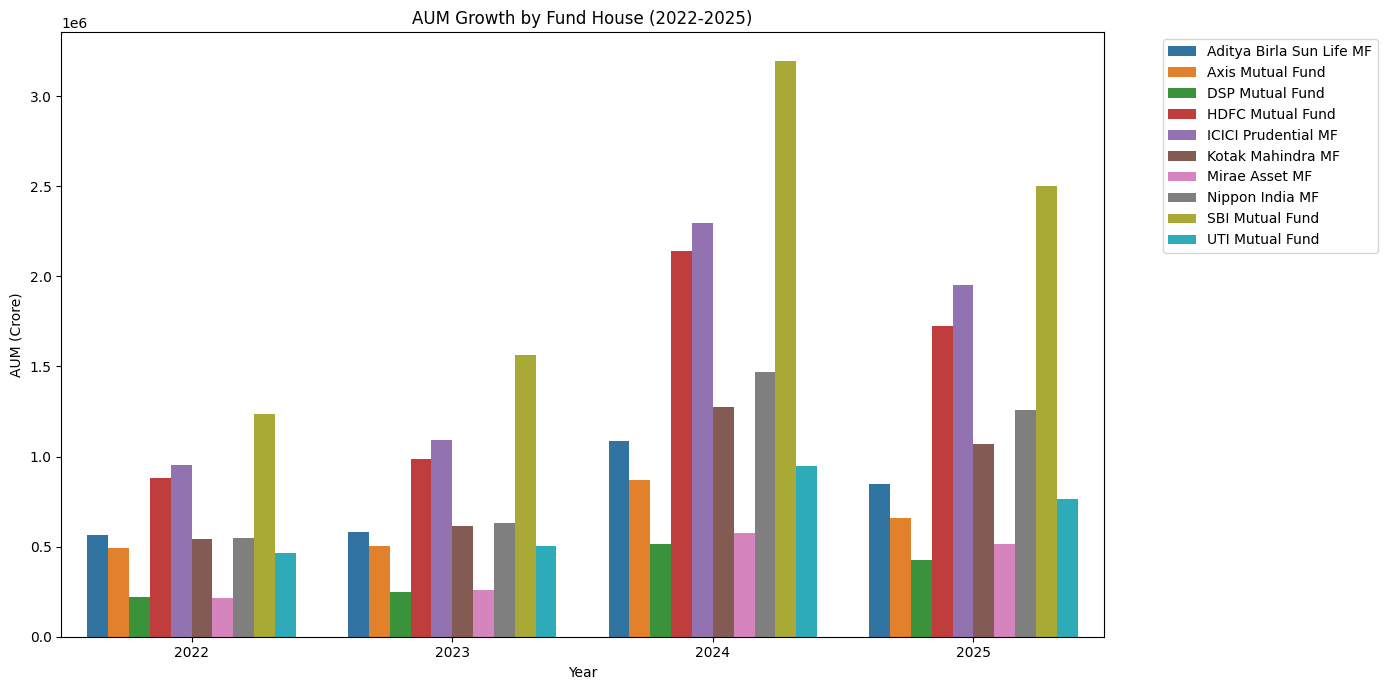

In [34]:
plt.figure(figsize=(14, 7))

sns.barplot(
    data=aum_summary,
    x="year",
    y="aum_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House (2022-2025)")
plt.xlabel("Year")
plt.ylabel("AUM (Crore)")
plt.xticks(rotation=0)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

## Insight 2

SBI Mutual Fund consistently maintained the highest AUM among all fund houses from 2022–2025.

AUM growth accelerated significantly in 2024, indicating strong investor confidence and increased mutual fund participation.

ICICI Prudential MF and HDFC Mutual Fund remained the second and third largest fund houses throughout the period.

In [35]:
plt.savefig("../reports/aum_growth.png", bbox_inches="tight")
print("AUM chart saved")

AUM chart saved


<Figure size 640x480 with 0 Axes>

In [36]:
sip.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01,11517,4.91,9.10,4.80,NaN
1,2022-02,11438,4.93,8.20,4.85,NaN
2,2022-03,12328,5.09,10.50,5.01,NaN
3,2022-04,11863,5.48,9.52,5.12,NaN
4,2022-05,12286,5.55,8.10,5.15,NaN


# SIP Inflow Trend Analysis

This chart tracks monthly SIP inflows from January 2022 to December 2025.

Objective:
- Understand investor participation trends
- Identify growth in systematic investing
- Highlight record SIP inflow months

## Insight 3

In [37]:
sip["month"] = pd.to_datetime(sip["month"])

sip.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01-01,11517,4.91,9.10,4.80,NaN
1,2022-02-01,11438,4.93,8.20,4.85,NaN
2,2022-03-01,12328,5.09,10.50,5.01,NaN
3,2022-04-01,11863,5.48,9.52,5.12,NaN
4,2022-05-01,12286,5.55,8.10,5.15,NaN


In [40]:
fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflows (2022-2025)"
)

fig.add_annotation(
    x="2025-12-01",
    y=31002,
    text="All-Time High: ₹31,002 Cr",
    showarrow=True,
    arrowhead=2
)

fig.show()

In [41]:
fig.write_image("../reports/sip_trend.png")

print("SIP trend chart saved")

SIP trend chart saved


## Insight 3

Monthly SIP inflows showed a strong upward trajectory from 2022 to 2025.

Investor participation increased steadily, culminating in an all-time high monthly SIP inflow of ₹31,002 Crore in December 2025.

The trend reflects growing retail investor confidence and increased adoption of disciplined long-term investing through SIPs.

In [42]:
category.head()


,month,category,net_inflow_crore
0,2024-04,Large Cap,2413.0
1,2024-04,Mid Cap,3897.0
2,2024-04,Small Cap,3533.0
3,2024-04,Flexi Cap,4947.0
4,2024-04,Large & Mid Cap,4214.0


In [43]:
category["month"] = pd.to_datetime(category["month"])

category.head()

,month,category,net_inflow_crore
0,2024-04-01,Large Cap,2413.0
1,2024-04-01,Mid Cap,3897.0
2,2024-04-01,Small Cap,3533.0
3,2024-04-01,Flexi Cap,4947.0
4,2024-04-01,Large & Mid Cap,4214.0


In [44]:
heatmap_data = category.pivot_table(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

heatmap_data.head()

month,2024-04-01,2024-05-01,2024-06-01,2024-07-01,2024-08-01,2024-09-01,2024-10-01,2024-11-01,2024-12-01,2025-01-01,2025-02-01,2025-03-01
category,,,,,,,,,,,,
ELSS,466.0,553.0,472.0,471.0,499.0,537.0,537.0,571.0,521.0,516.0,437.0,500.0
Flexi Cap,4947.0,5529.0,4478.0,4869.0,5562.0,5397.0,6004.0,6111.0,4654.0,5603.0,6068.0,4767.0
Gilt,784.0,836.0,864.0,959.0,952.0,925.0,898.0,704.0,831.0,744.0,942.0,956.0
Hybrid,2955.0,3487.0,3163.0,3291.0,3684.0,3015.0,3314.0,3264.0,3538.0,2967.0,3360.0,2830.0
Large & Mid Cap,4214.0,4368.0,4610.0,5023.0,5411.0,4528.0,4581.0,5556.0,4878.0,4816.0,5524.0,4243.0


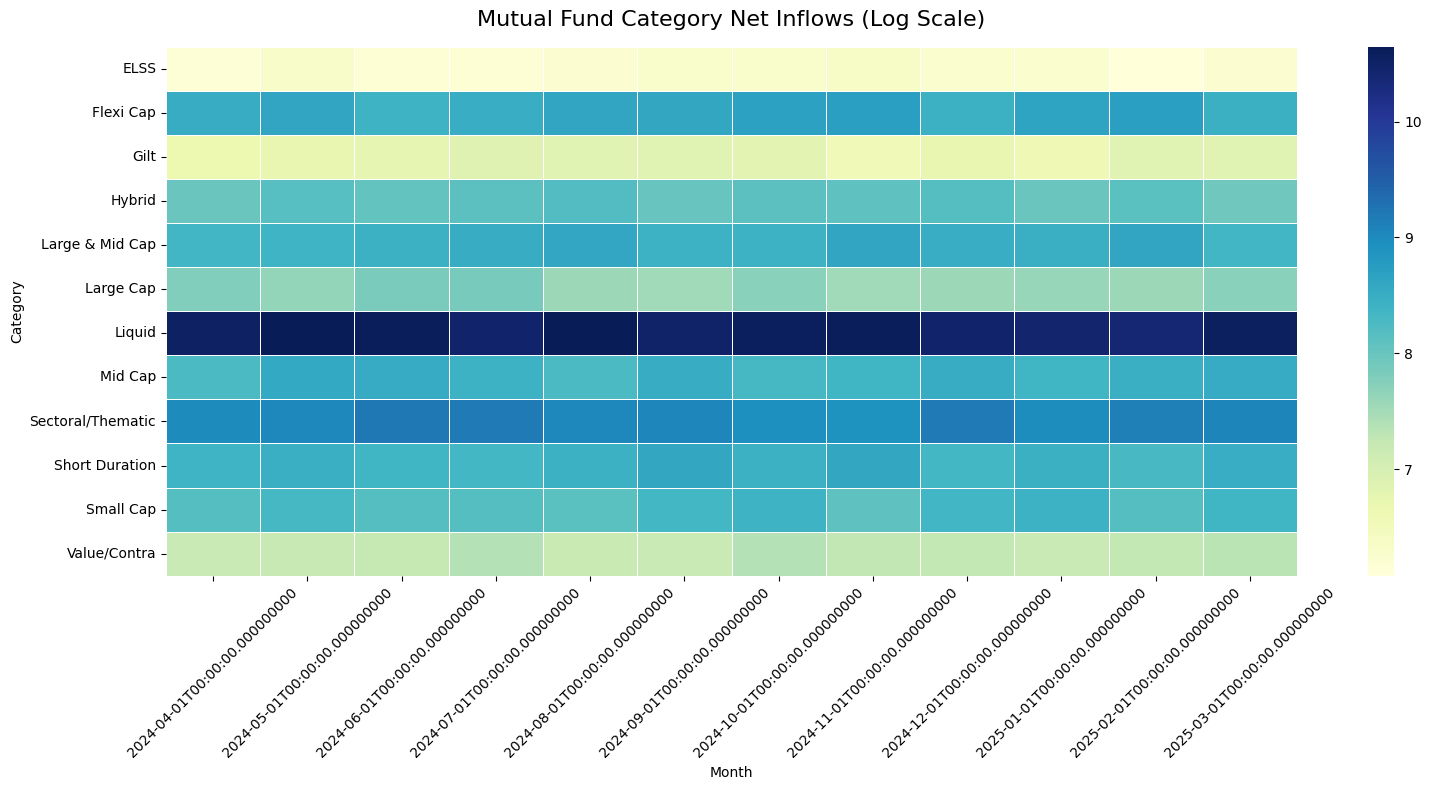

In [46]:
import numpy as np

heatmap_log = np.log1p(heatmap_data)

plt.figure(figsize=(16,8))

sns.heatmap(
    heatmap_log,
    cmap="YlGnBu",
    linewidths=0.5,
    linecolor="white"
)

plt.title(
    "Mutual Fund Category Net Inflows (Log Scale)",
    fontsize=16,
    pad=15
)

plt.xlabel("Month")
plt.ylabel("Category")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [47]:
plt.savefig("../reports/category_heatmap.png", bbox_inches="tight")

print("Category heatmap saved")

Category heatmap saved


<Figure size 640x480 with 0 Axes>

## Insight 4

Flexi Cap, Large & Mid Cap, and Mid Cap categories consistently attracted strong inflows during the observed period.

The heatmap highlights periods of increased investor interest in diversified equity categories, particularly during market expansion phases.

Category preferences shifted over time, reflecting changing investor risk appetite and market conditions.

In [48]:
transactions.head()


,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [49]:
transactions["age_group"].value_counts()

age_group
26-35    13463
36-45     8146
18-25     4916
46-55     3779
56+       2474
Name: count, dtype: int64

In [50]:
transactions["gender"].value_counts()

gender
Male      21809
Female    10969
Name: count, dtype: int64

In [51]:
transactions[["age_group", "amount_inr"]].head()

,age_group,amount_inr
0,56+,1834
1,18-25,392882
2,36-45,912
3,36-45,1102
4,26-35,8682


In [52]:
transactions["age_group"].value_counts()

age_group
26-35    13463
36-45     8146
18-25     4916
46-55     3779
56+       2474
Name: count, dtype: int64

In [53]:
transactions["gender"].value_counts()

gender
Male      21809
Female    10969
Name: count, dtype: int64

# Investor Demographics Analysis

This section analyzes investor age groups, gender participation, and investment behavior.

## Insight 5

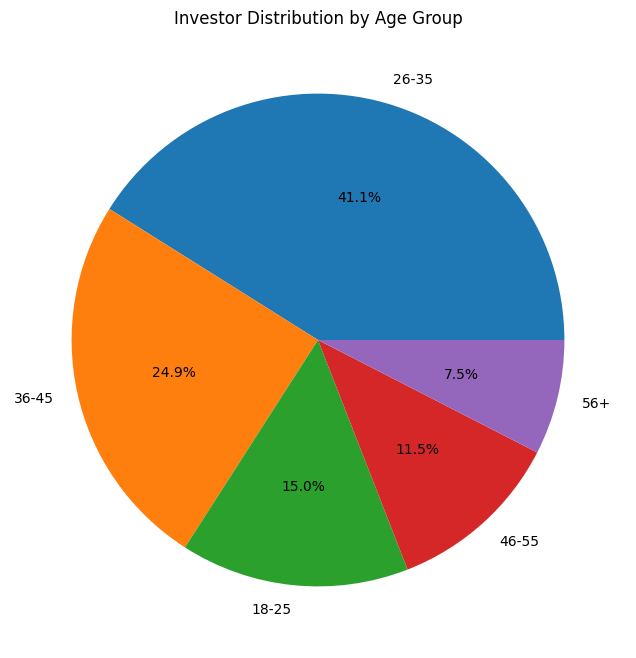

In [54]:
age_counts = transactions["age_group"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct="%1.1f%%"
)

plt.title("Investor Distribution by Age Group")

plt.show()

In [55]:
plt.savefig("../reports/age_group_pie.png", bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

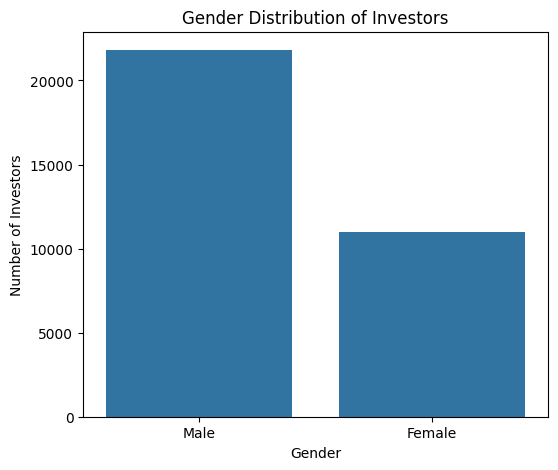

In [56]:
gender_counts = transactions["gender"].value_counts()

plt.figure(figsize=(6,5))

sns.barplot(
    x=gender_counts.index,
    y=gender_counts.values
)

plt.title("Gender Distribution of Investors")
plt.xlabel("Gender")
plt.ylabel("Number of Investors")

plt.show()

In [57]:
plt.savefig("../reports/gender_split.png", bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

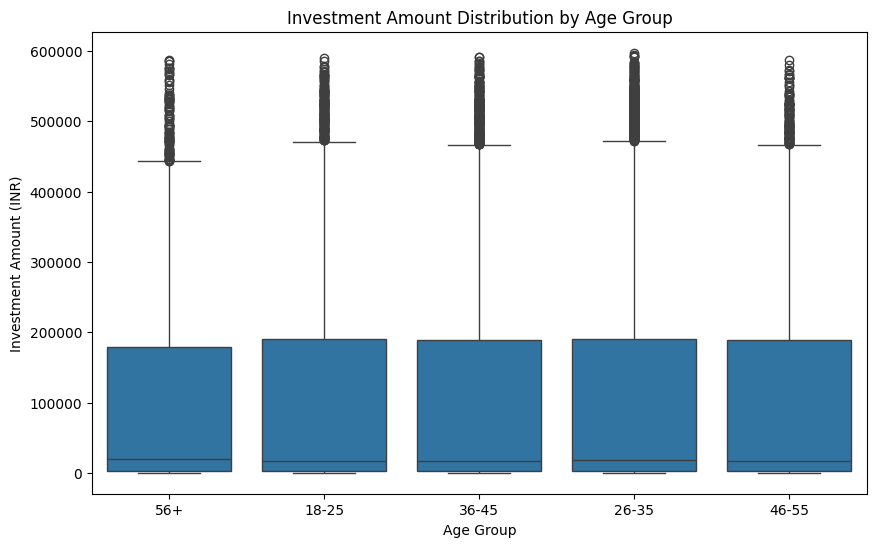

In [58]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=transactions,
    x="age_group",
    y="amount_inr"
)

plt.title("Investment Amount Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Investment Amount (INR)")

plt.show()

In [59]:
plt.savefig("../reports/age_group_boxplot.png", bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

## Insight 5

The 26–35 age group accounted for the largest share of investors, followed by the 36–45 segment.

Male investors represented approximately two-thirds of total transactions, while female participation accounted for roughly one-third.

Investment amounts varied across age groups, with older investors generally showing a wider range of transaction values.

In [60]:
transactions.columns

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='object')

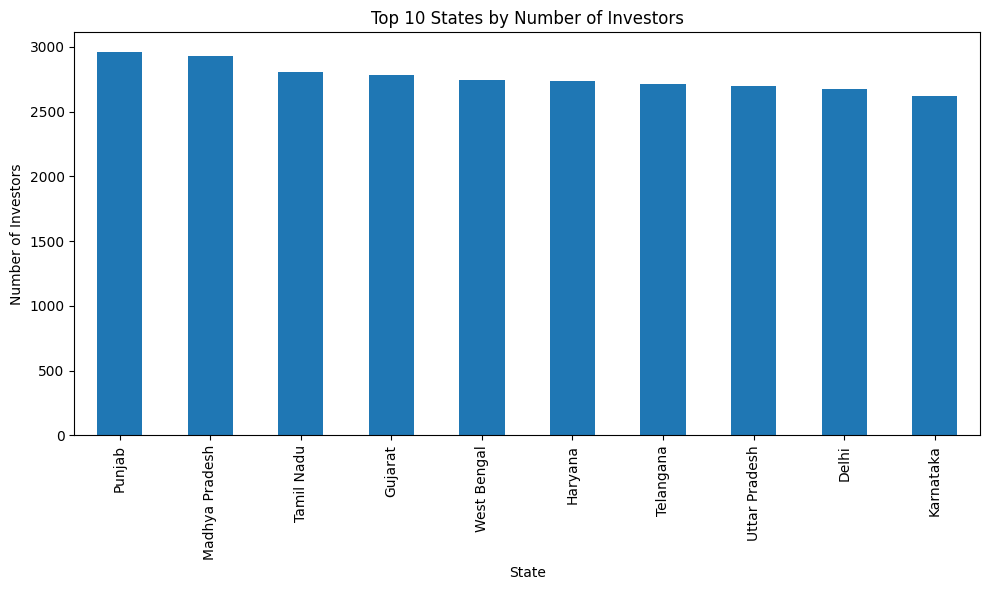

In [61]:
state_counts = transactions["state"].value_counts().head(10)

plt.figure(figsize=(10,6))
state_counts.plot(kind="bar")

plt.title("Top 10 States by Number of Investors")
plt.xlabel("State")
plt.ylabel("Number of Investors")

plt.tight_layout()
plt.show()

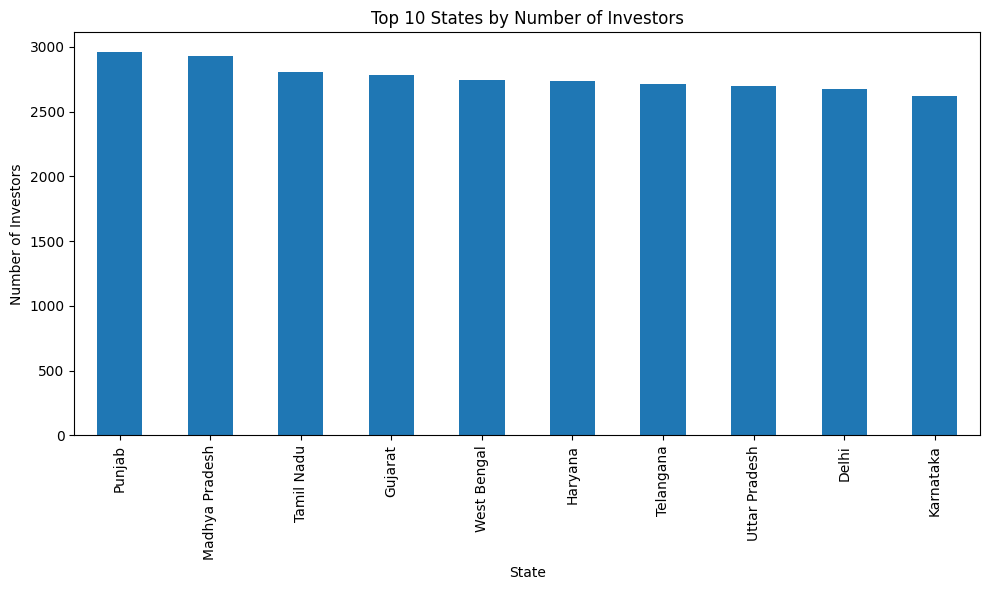

In [62]:
plt.figure(figsize=(10,6))
state_counts.plot(kind="bar")

plt.title("Top 10 States by Number of Investors")
plt.xlabel("State")
plt.ylabel("Number of Investors")

plt.tight_layout()

plt.savefig("../reports/state_distribution.png")
plt.show()

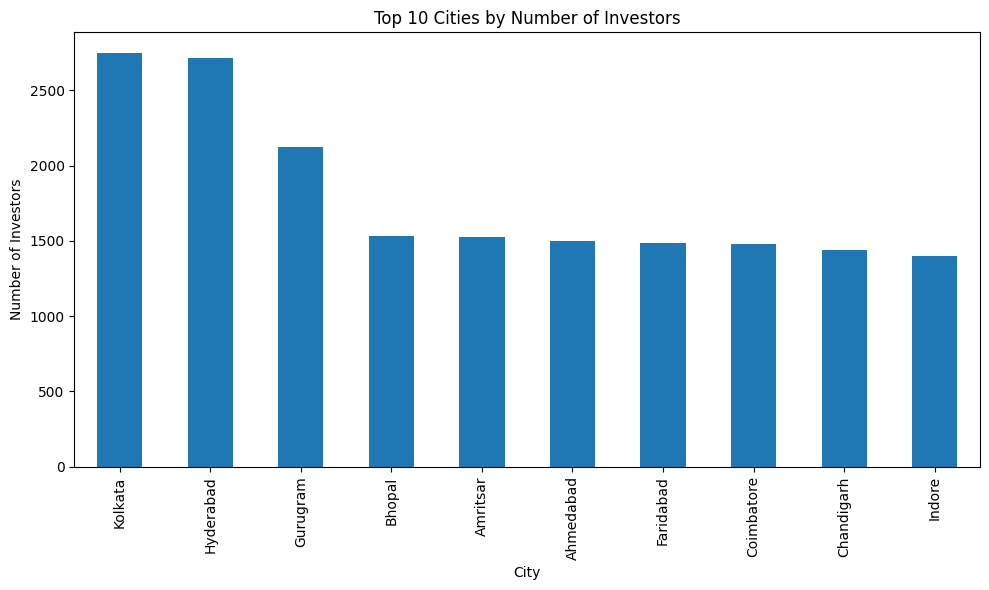

In [63]:
city_counts = transactions["city"].value_counts().head(10)

plt.figure(figsize=(10,6))
city_counts.plot(kind="bar")

plt.title("Top 10 Cities by Number of Investors")
plt.xlabel("City")
plt.ylabel("Number of Investors")

plt.tight_layout()
plt.show()

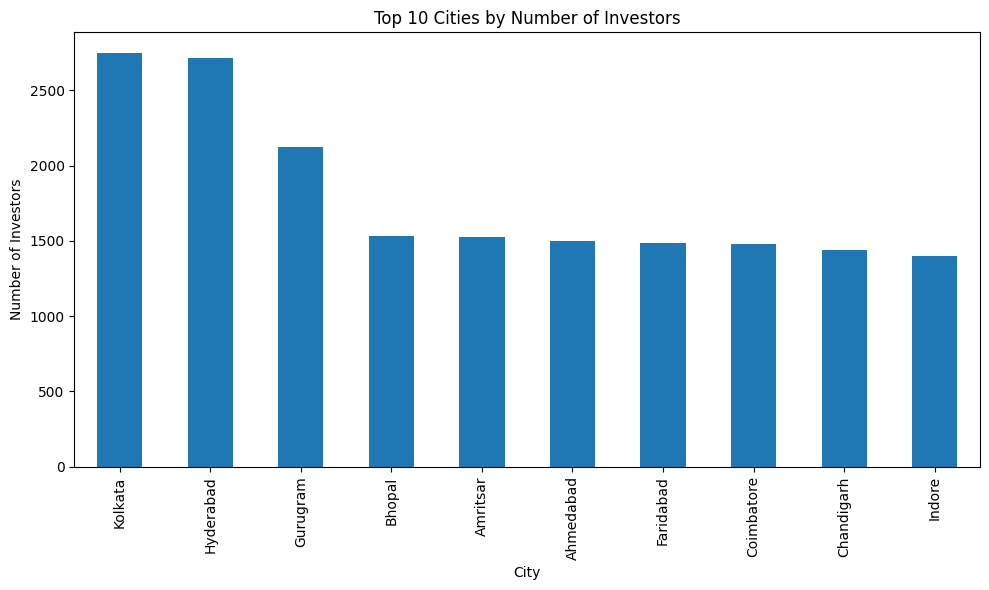

In [64]:
plt.figure(figsize=(10,6))
city_counts.plot(kind="bar")

plt.title("Top 10 Cities by Number of Investors")
plt.xlabel("City")
plt.ylabel("Number of Investors")

plt.tight_layout()

plt.savefig("../reports/city_distribution.png")
plt.show()

In [65]:
transactions["city_tier"].value_counts()

city_tier
T30    21719
B30    11059
Name: count, dtype: int64

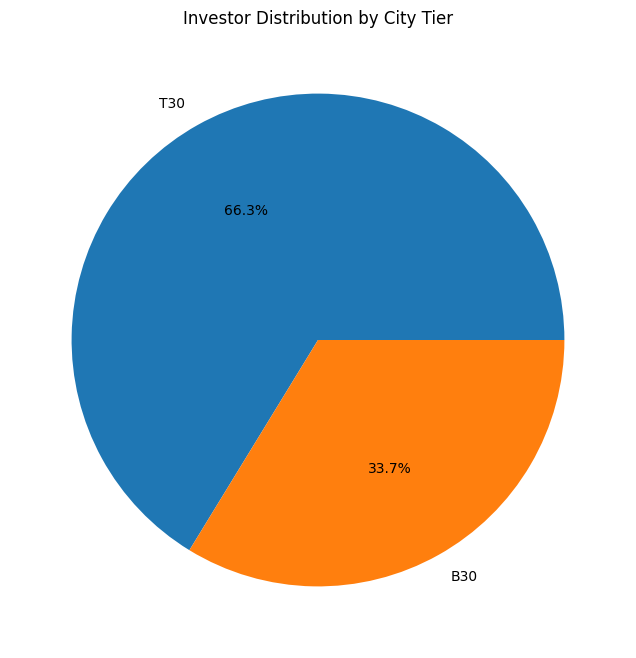

In [66]:
tier_counts = transactions["city_tier"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    tier_counts,
    labels=tier_counts.index,
    autopct="%1.1f%%"
)

plt.title("Investor Distribution by City Tier")

plt.show()

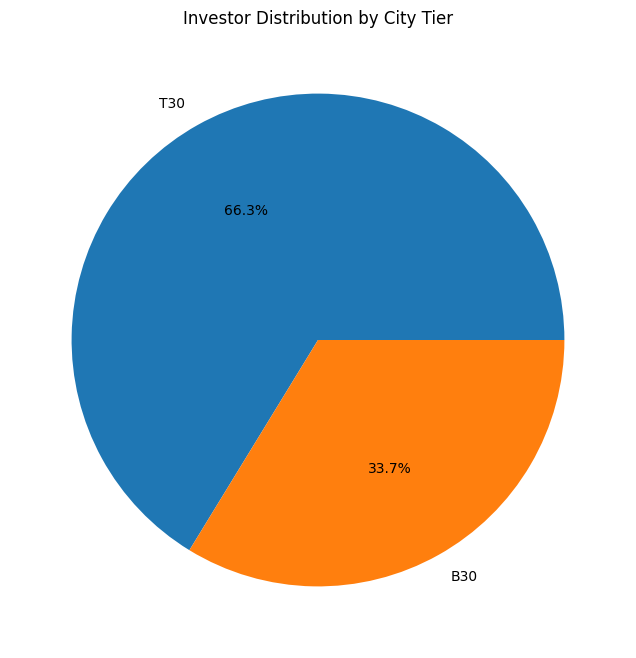

In [67]:
plt.figure(figsize=(8,8))

plt.pie(
    tier_counts,
    labels=tier_counts.index,
    autopct="%1.1f%%"
)

plt.title("Investor Distribution by City Tier")

plt.savefig("../reports/city_tier_distribution.png")

plt.show()

# Geographic Distribution Analysis

## Objective
Understand where mutual fund investors are concentrated across India.

## Insight 1
Investor participation is concentrated in a few major states.

## Insight 2
Metro and large urban centers contribute the highest number of investors.

## Insight 3
Tier-1 cities dominate mutual fund adoption, reflecting stronger financial awareness and accessibility.

## Insight 4
Smaller cities are participating increasingly, indicating growing penetration of mutual funds beyond metros.